## Gradient Descent Extensions: Momentum and Adam

In this laboratory session, you will explore two popular extensions of basic Gradient Descent:
1.	Momentum-based Gradient Descent
2.	Adam (Adaptive Moment Estimation)

We will test these methods on three classical benchmark functions in 2D space:
- **Sphere**: a simple, convex, unimodal function that is relatively easy to optimize.
- **Rosenbrock**: features a narrow valley, making convergence more difficult.
- **Rastrigin**: contains many local minima, making it challenging to escape suboptimal points.

By the end of this lab, you should understand how momentum and adaptive step-size techniques help accelerate gradient-based optimization, especially on surfaces with poor curvature or local traps.

### Test Functions
You have been given implementations of the three test functions (Sphere, Rosenbrock, and Rastrigin) along with their gradients, all inheriting from the abstract `Problem` class.

In [1]:
import numpy as np
from abc import ABC, abstractmethod

class Problem(ABC):
    @abstractmethod
    def __call__(self, x: np.ndarray) -> float:
        """Compute the function value at point x."""
        raise NotImplementedError
    
    @abstractmethod
    def grad(self, x: np.ndarray) -> np.ndarray:
        """Compute the gradient at point x."""
        raise NotImplementedError

class Sphere(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(x**2)
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        return 2 * x

class Rosenbrock(Problem):
    def __call__(self, x: np.ndarray) -> float:
        return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        grad = np.zeros_like(x)
        n = x.size
        grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
        for i in range(1, n - 1):
            grad[i] = 200 * (x[i] - x[i-1]**2) - 400 * x[i] * (x[i+1] - x[i]**2) - 2 * (1 - x[i])
        grad[-1] = 200 * (x[-1] - x[-2]**2)
        return grad

class Rastrigin(Problem):
    def __call__(self, x: np.ndarray) -> float:
        A = 10
        n = x.size
        return A * n + np.sum(x**2 - A * np.cos(2 * np.pi * x))
    
    def grad(self, x: np.ndarray) -> np.ndarray:
        A = 10
        return 2 * x + 2 * np.pi * A * np.sin(2 * np.pi * x)

### Visualization Tools
Here are some already implemented functions that you can use to produce visualizations:

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

def prepare_mesh_grid(
    problem: Problem,
    bounds: tuple[float, float] = (-5.0, 5.0),
    grid_size: int = 50,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    x_vals = np.linspace(bounds[0], bounds[1], grid_size)
    y_vals = np.linspace(bounds[0], bounds[1], grid_size)
    X, Y = np.meshgrid(x_vals, y_vals)

    Z = np.zeros_like(X)
    for i in range(grid_size):
        for j in range(grid_size):
            xy = np.array([X[i, j], Y[i, j]])
            Z[i, j] = problem(xy)

    return X, Y, Z, x_vals, y_vals


def plot_3d_surface(
    problem: Problem,
    grid_size: int = 50,
):
    X, Y, Z, _, _ = prepare_mesh_grid(problem=problem, grid_size=grid_size)

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, Z, cmap="viridis", edgecolor="none")

    ax.set_title(problem.__class__.__name__)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("f(x, y)")

    fig.colorbar(surf, shrink=0.5, aspect=10)
    plt.tight_layout()
    plt.show()

def plot_contour_and_paths(
    problem: Problem,
    paths: list[np.ndarray],
    grid_size: int = 200,
    title: str = "",
):
    """
    Create an interactive contour plot of a 2D function and overlay multiple optimization paths.

    Args:
        problem: An instance of a Problem class.
        paths: List of numpy arrays; each array is of shape (epochs, 2) containing an optimization trajectory.
        title: Title for the plot.
    """
    _, _, Z, x_vals, y_vals = prepare_mesh_grid(problem, grid_size=grid_size)

    fig = go.Figure(
        data=go.Contour(
            x=x_vals,
            y=y_vals,
            z=Z,
            colorscale="Viridis",
            contours=dict(showlines=False),
            colorbar=dict(title="Function Value"),
        )
    )

    colors = ['red', 'blue', 'green', 'purple', 'orange', 'cyan', 'magenta', 'yellow', 'pink', 'brown']
    
    for idx, path in enumerate(paths):
        color_idx = idx % len(colors)
        fig.add_trace(
            go.Scatter(
                x=path[:, 0],
                y=path[:, 1],
                mode="lines+markers",
                marker=dict(size=4),
                line=dict(width=2, color=colors[color_idx]),
                name=f"Run {idx+1}",
                showlegend=True,
            )
        )

    fig.update_layout(
        title=title, xaxis_title="x", yaxis_title="y", width=800, height=700,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    fig.show()

### 1. Getting familiar with optimization test problems
Understand the landscapes of the test functions to predict optimization challenges.
Visualize each function. Use `plot_3d_surface` to generate a 3D surface plot for each function (Sphere, Rosenbrock, Rastrigin). Use `plot_contour_and_paths` with an empty paths list to generate a 2D contour plot for each function.

Which function appears easiest to optimize? Hardest? Why?

In [8]:
sphere = Sphere()
rosenbrock = Rosenbrock()
rastrigin = Rastrigin()

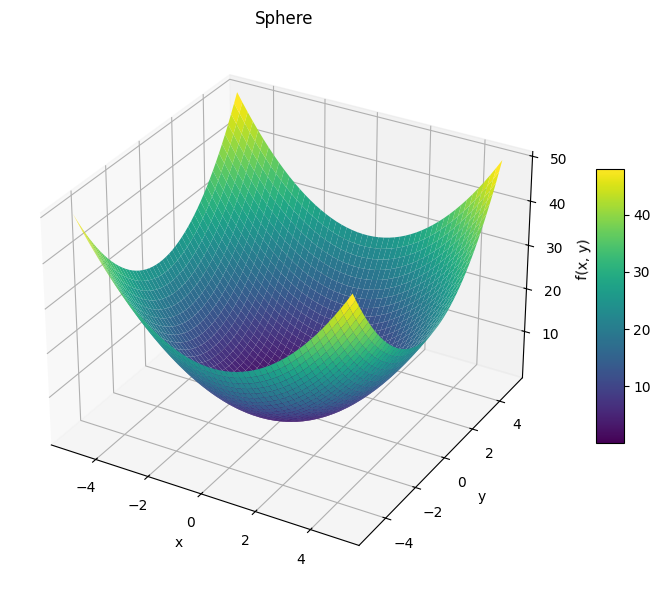

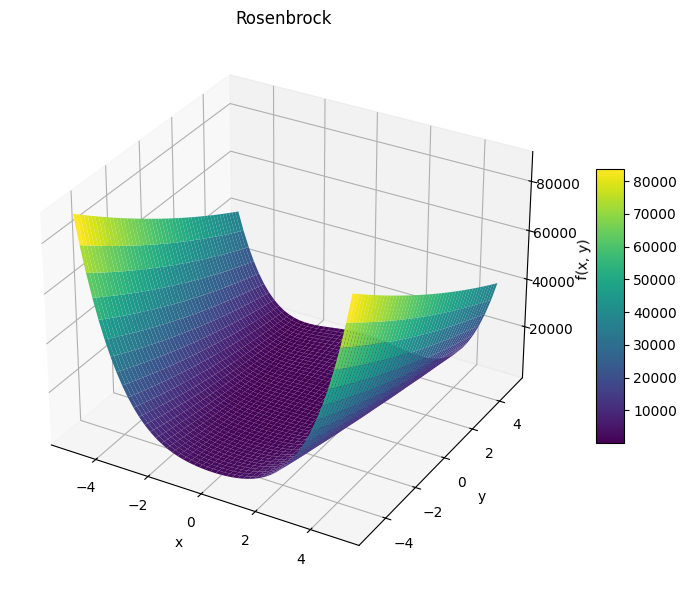

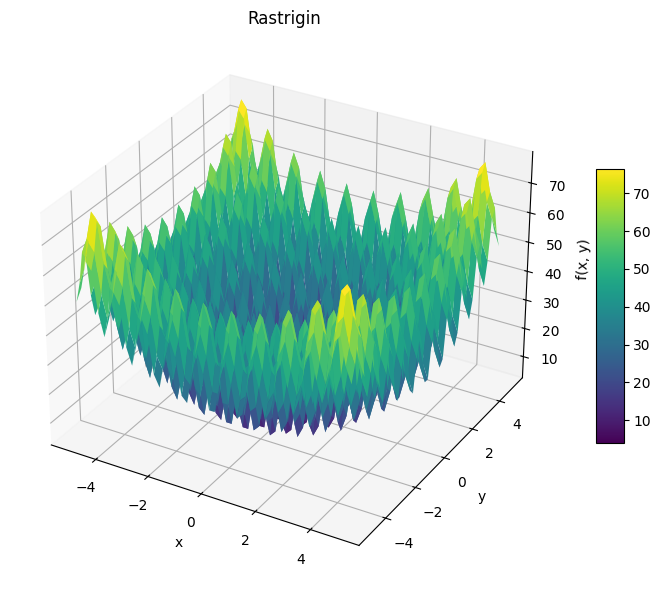

In [9]:
plot_3d_surface(sphere)
plot_3d_surface(rosenbrock)
plot_3d_surface(rastrigin)

plot_contour_and_paths(sphere, [])
plot_contour_and_paths(rosenbrock, [])
plot_contour_and_paths(rastrigin, [])

### 2. Momentum method

Your task is to implement the Momentum optimizer with the interface:

In [ ]:
def momentum(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta: float = 0.9,
    number_of_epochs: int = 1000,
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    w = initial_solution.copy()
    v = np.zeros(w.shape[0])

    positions = np.zeros((number_of_epochs, w.shape[0]))
    function_values = np.zeros((number_of_epochs,))
    velocity_norms = np.zeros((number_of_epochs,))

    for epoch in range(number_of_epochs):
        v = beta * v + alpha * problem.grad(w)
        w = w - v

        positions[epoch] = w
        velocity_norms[epoch] = np.linalg.norm(v)
        function_values[epoch] = problem(w)
    #

    return positions, function_values, velocity_norms
#

Where:
- initial_solution is your starting point.
- alpha is the learning rate.
- beta is the momentum parameter (commonly 0.9).

Returns a tuple of:
- positions: np.ndarray of shape (number_of_epochs, dim) — the optimization path.
- function_values: np.ndarray of shape (number_of_epochs,) — function value at each epoch.
- velocity_norms: np.ndarray of shape (number_of_epochs,) — velocity norm at each epoch.

### 3. Experiments with Momentum

Observe how Momentum performs on different functions. Use following parameters:
- `initial_solution = np.array([2.0, 2.0])`, 
- `alpha = 0.01`, 
- `beta = 0.9`, 
- `number_of_epochs = 100`. 

For each function, plot:
- Function value vs. epoch.
- For Rosenbrock and Rastrigin functions, experiment with decreasing the learning rate `alpha` (try values like 0.001 and 0.0001) to observe how it affects convergence.
- Velocity norm (e.g `np.linalg.norm`) vs. epoch. Note: velocity is a **vector** (one component per dimension), so we cannot plot it directly as a single value. Instead, we take its norm — a scalar that measures the overall magnitude of the velocity vector.

How does the velocity norm evolve? Does it correlate with convergence speed?

In [36]:
initial_solution = np.array([2.0, 2.0])
alpha, beta = 0.01, 0.9
number_of_epochs = 100

positions_momentum_sphere, functions_values_momentum_sphere, velocity_norms_momentum_sphere = momentum(sphere, initial_solution, alpha, beta, number_of_epochs)
positions_momentum_rosenbrock, functions_values_momentum_rosenbrock, velocity_norms_momentum_rosenbrock = momentum(rosenbrock, initial_solution, alpha, beta, number_of_epochs)
positions_momentum_rastrigin, functions_values_momentum_rastrigin, velocity_norms_momentum_rastrigin = momentum(rastrigin, initial_solution, alpha, beta, number_of_epochs)

C:\Users\User\AppData\Local\Temp\ipykernel_20840\2562006258.py:24: RuntimeWarning: overflow encountered in square
  return np.sum(100.0 * (x[1:] - x[:-1]**2)**2 + (1 - x[:-1])**2)
C:\Users\User\AppData\Local\Temp\ipykernel_20840\2562006258.py:29: RuntimeWarning: overflow encountered in scalar multiply
  grad[0] = -400 * x[0] * (x[1] - x[0]**2) - 2 * (1 - x[0])
C:\Users\User\AppData\Local\Temp\ipykernel_20840\4256692312.py:16: RuntimeWarning: invalid value encountered in add
  v = beta * v + alpha * problem.grad(w)


In [23]:
# def plot_2d(X: np.ndarray, y: np.ndarray, title: str = "", xlabel: str = "", ylabel: str = "", label: str = "", figsize: tuple[int, int] = (10, 8)) -> None:
#     plt.figure(figsize=figsize)
#     plt.plot(X, y, label=label)

#     if title: plt.title(title)
#     if xlabel: plt.xlabel(xlabel)
#     if ylabel: plt.ylabel(ylabel)
#     if label: plt.legend()

#     plt.tight_layout()
#     plt.show()
# #

def plot_2d(X: np.ndarray, y: np.ndarray, ax: plt.Axes | None = None, title: str = "", xlabel: str = "", ylabel: str = "", label: str = "", figsize: tuple[int, int] = (10, 8)) -> None:
    if ax is None: _, ax = plt.subplots(figsize=figsize)

    ax.plot(X, y, label=label)
    if title: ax.set_title(title)
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    if label: ax.legend()
    plt.tight_layout()
#

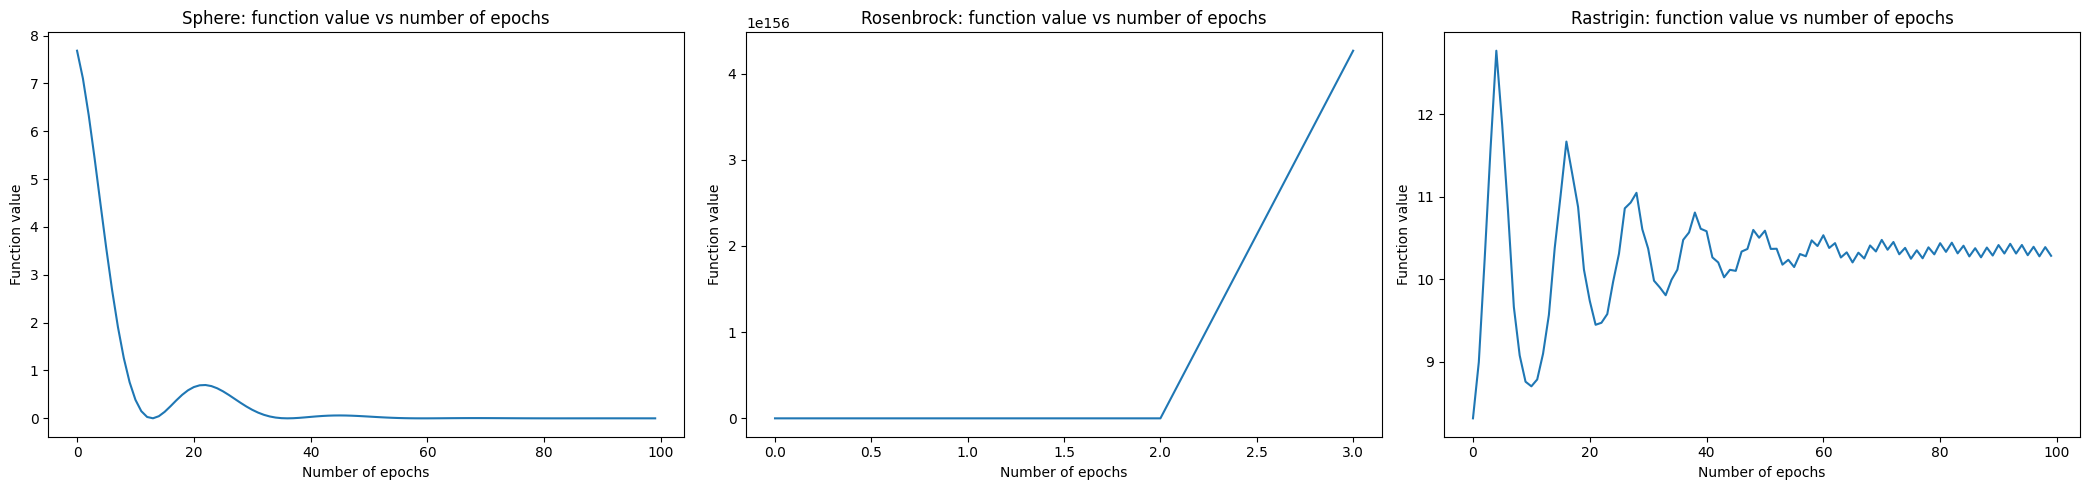

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

plot_2d(range(number_of_epochs), functions_values_momentum_sphere,     ax=axes[0], title='Sphere: function value vs number of epochs',     xlabel='Number of epochs', ylabel='Function value')
plot_2d(range(number_of_epochs), functions_values_momentum_rosenbrock, ax=axes[1], title='Rosenbrock: function value vs number of epochs', xlabel='Number of epochs', ylabel='Function value')
plot_2d(range(number_of_epochs), functions_values_momentum_rastrigin,  ax=axes[2], title='Rastrigin: function value vs number of epochs',  xlabel='Number of epochs', ylabel='Function value')

plt.show()

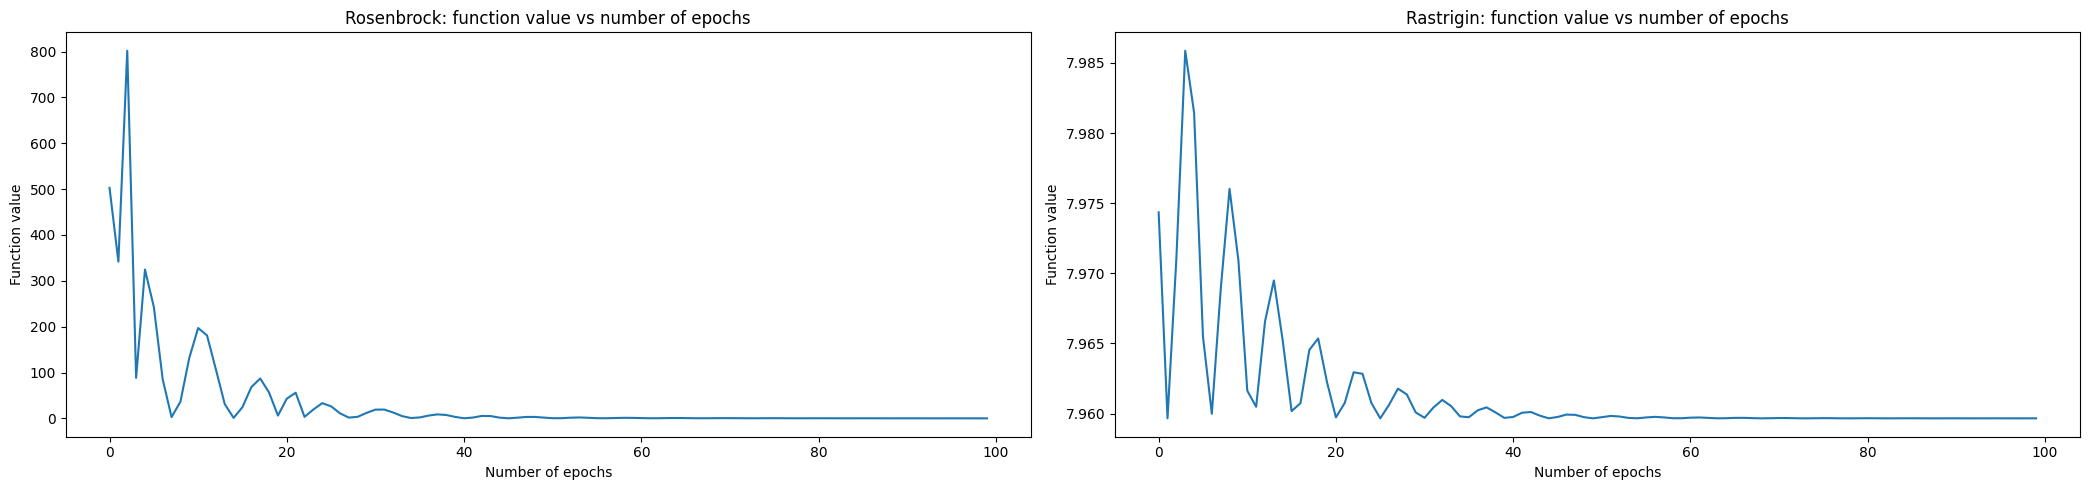

In [39]:
alpha = 0.001

positions_momentum_rosenbrock, functions_values_momentum_rosenbrock, velocity_norms_momentum_rosenbrock = momentum(rosenbrock, initial_solution, alpha, beta, number_of_epochs)
positions_momentum_rastrigin, functions_values_momentum_rastrigin, velocity_norms_momentum_rastrigin = momentum(rastrigin, initial_solution, alpha, beta, number_of_epochs)

fig, axes = plt.subplots(1, 2, figsize=(21, 5))

plot_2d(range(number_of_epochs), functions_values_momentum_rosenbrock, ax=axes[0], title='Rosenbrock: function value vs number of epochs', xlabel='Number of epochs', ylabel='Function value')
plot_2d(range(number_of_epochs), functions_values_momentum_rastrigin,  ax=axes[1], title='Rastrigin: function value vs number of epochs',  xlabel='Number of epochs', ylabel='Function value')

plt.show()

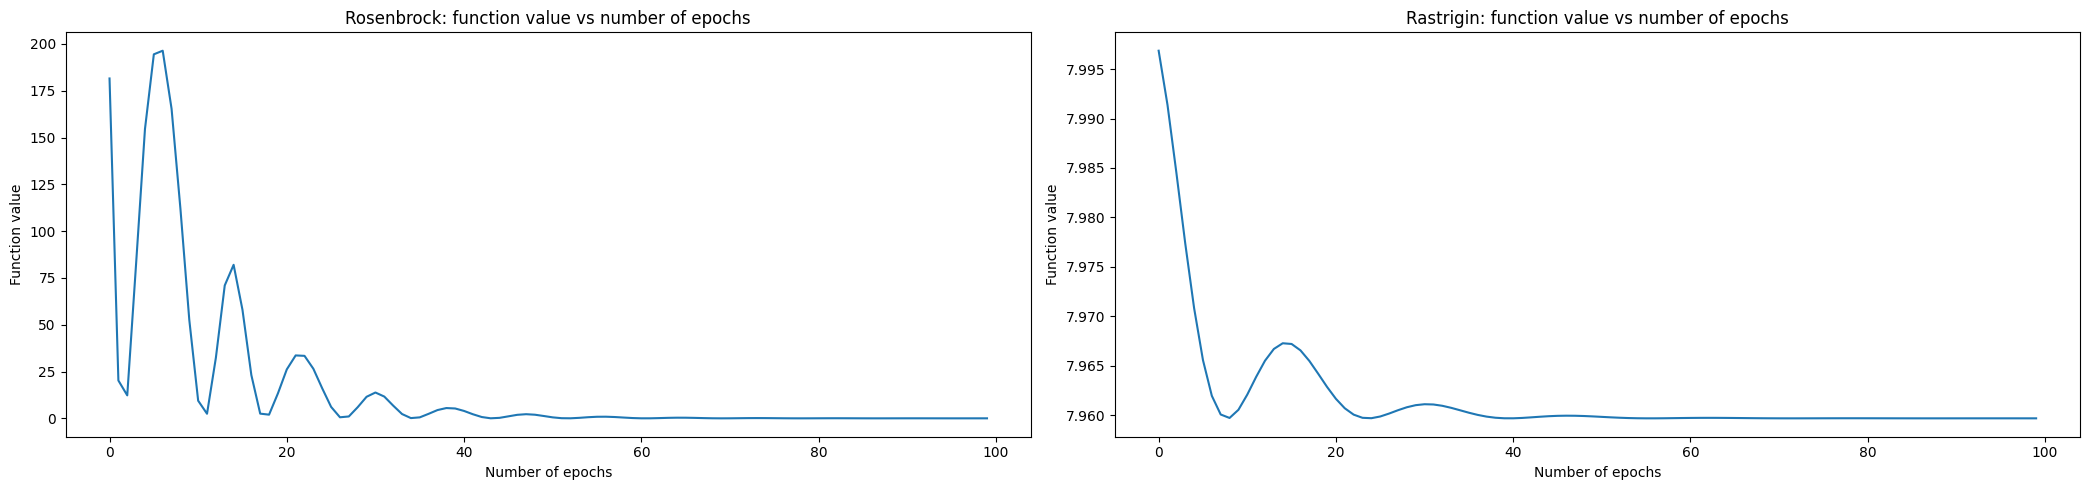

In [40]:
alpha = 0.0001

positions_momentum_rosenbrock, functions_values_momentum_rosenbrock, velocity_norms_momentum_rosenbrock = momentum(rosenbrock, initial_solution, alpha, beta, number_of_epochs)
positions_momentum_rastrigin, functions_values_momentum_rastrigin, velocity_norms_momentum_rastrigin = momentum(rastrigin, initial_solution, alpha, beta, number_of_epochs)

fig, axes = plt.subplots(1, 2, figsize=(21, 5))

plot_2d(range(number_of_epochs), functions_values_momentum_rosenbrock, ax=axes[0], title='Rosenbrock: function value vs number of epochs', xlabel='Number of epochs', ylabel='Function value')
plot_2d(range(number_of_epochs), functions_values_momentum_rastrigin,  ax=axes[1], title='Rastrigin: function value vs number of epochs',  xlabel='Number of epochs', ylabel='Function value')

plt.show()

### 4. Momentum Hyperparameters

Fix `alpha = 1e-4, initial_solution = np.array([2.0, 2.0]), number_of_epochs = 100`.
Use $\beta \in [0.5, 0.75, 0.9, 0.95, 0.99]$ on the Rosenbrock function. How does increasing $\beta$ affect convergence? Stability?

### 5. Adam
Implement the Adam optimizer:


In [ ]:
def adam(
    problem: Problem,
    initial_solution: np.ndarray,
    alpha: float,
    beta1: float,
    beta2: float,
    number_of_epochs: int,
    epsilon: float = 1e-8
) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    ...

Where:
- beta1 is the exponential decay rate for first moment estimates (similar to momentum).
- beta2 is the exponential decay rate for second moment estimates (variance).

Returns a tuple of:
- positions: np.ndarray of shape (number_of_epochs, dim) — the optimization path.
- function_values: np.ndarray of shape (number_of_epochs,) — function value at each epoch.
- gradient_norms: np.ndarray of shape (number_of_epochs,) — gradient norm at each epoch.

### 6. Comparing Adam with Momentum
Run both optimizers on Sphere, Rosenbrock and Rastrigin. Use: 
- `initial_solution = np.array([2.0, 2.0]), number_of_epochs = 100`.
- Momentum: `alpha = 0.01, beta = 0.9`.
- Adam: `alpha = 0.01, beta1 = 0.9, beta2 = 0.999, epsilon = 1e-8`.


Visualize optimization paths. Use `plot_contour_and_paths` to overlay paths from both methods.
Plot function value vs. epoch for both methods.